## Import the packages

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import os
import time
import pickle

## Load the data and explore

In [13]:
data = pd.read_csv('customer_data.csv')

In [14]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Preprocess Data

In [17]:
# remove unnecessarz columns
data = data.drop(columns=['RowNumber','CustomerId','Surname']) #Simplify the dataset
data = data.dropna()  # Simple example of dropping missing values

In [18]:
# encode categorical data
# first inspect them
object_cols = data.select_dtypes(include='object')
display(object_cols.head())

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female


These are the categorical features: ['Geography', 'Gender']

In [19]:
data['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [20]:
data['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [21]:
categorical_cols = ['Geography', 'Gender']

In [22]:
ct = ColumnTransformer(
    transformers=[
        ('encode', OneHotEncoder(drop='first'), ['Geography', 'Gender'])
    ],
    remainder='passthrough'
)

data = ct.fit_transform(data)

In [23]:
# Get column names from the transformer
encoded_cols = ct.get_feature_names_out()

# Convert back to DataFrame for readability
data = pd.DataFrame(data, columns=encoded_cols)
data.columns = data.columns.str.replace('encode__', '').str.replace('remainder__', '')
data.head()

,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.0,0.0,0.0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,0.0,1.0,0.0,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,0.0,0.0,0.0,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,0.0,0.0,0.0,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,0.0,1.0,0.0,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0


In [24]:
data = data.rename(columns= {'Exited': 'Label'})

## Split the data

In [25]:
X = data.drop('Label', axis=1)
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale numeric features

In [28]:
encoded_cols = [col for col in X_train.columns if any(cat in col for cat in categorical_cols)]
numeric_cols = [col for col in X_train.columns if col not in encoded_cols]

# Scale only numeric columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Build and train the model

In [29]:
class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super(ChurnModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)           # Stabilizes training
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)           # 0.3 is better for small datasets

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)                         # Raw logits — no sigmoid here
        return x

model = ChurnModel(input_dim=X_train_scaled.shape[1])

In [31]:
# Convert data to tensors once — not inside the loop
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [32]:
# Use DataLoader for batched training
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)


In [33]:
# --- Class weight to handle imbalance ---
num_stayed = (y_train.values == 0).sum()
num_churned = (y_train.values == 1).sum()
pos_weight = torch.tensor([num_stayed / num_churned])
print(f'Class weight applied: {pos_weight.item():.2f}x penalty for missing churners')


Class weight applied: 3.87x penalty for missing churners


In [34]:
# this applies sigmoid internally
criterion = nn.BCEWithLogitsLoss()

In [35]:
# optimizer with weight_decay for L2 regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [36]:
EPOCHS = 50 # 10 is often too few for tabular data, try others according to the first experiments

In [37]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Print every 10 epochs to avoid clutter
    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}')

print('Training complete.')

Epoch [10/50] Loss: 0.3718
Epoch [20/50] Loss: 0.3559
Epoch [30/50] Loss: 0.3524
Epoch [40/50] Loss: 0.3483
Epoch [50/50] Loss: 0.3456
Training complete.


## Evaluation

In [38]:
def evaluate_model(model, X_test_tensor, y_test_tensor, y_test):
    model.eval()
    with torch.no_grad():  # No gradient computation for evaluation
        outputs = model(X_test_tensor).squeeze()
        probabilities = torch.sigmoid(outputs).numpy()  # Apply sigmoid since model outputs raw logits
        predictions = (probabilities > 0.5).astype(int)

    # Overall accuracy
    accuracy = np.mean(predictions == y_test.values) * 100
    print(f'Test Accuracy: {accuracy:.2f}%\n')

    # Precision, Recall, F1 per class
    print('Classification Report:')
    print(classification_report(y_test, predictions, target_names=['Stayed', 'Churned']))

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)
    print('Confusion Matrix:')
    print(cm)

    # AUC-ROC score
    auc = roc_auc_score(y_test, probabilities)
    print(f'\nAUC-ROC Score: {auc:.4f}')

    return predictions, probabilities, cm

predictions, probabilities, cm = evaluate_model(model, X_test_tensor, y_test_tensor, y_test)

Test Accuracy: 86.15%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1607
     Churned       0.73      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Confusion Matrix:
[[1540   67]
 [ 210  183]]

AUC-ROC Score: 0.8619


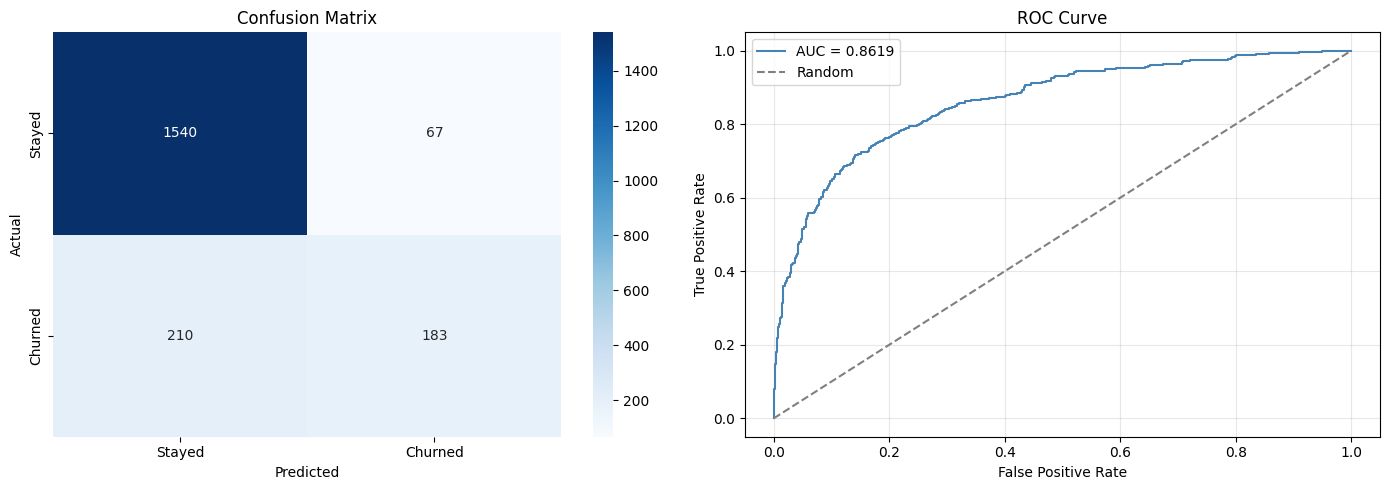

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Optimization

In [42]:
# --- Quantize the model ---
model.eval()  # Must be in eval mode before quantization
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)


/tmp/ipykernel_355/3986710009.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [43]:
# to compare the model sizes, save both
torch.save(model.state_dict(), 'original.pth')
torch.save(quantized_model.state_dict(), 'quantized.pth')

In [44]:
original_size = os.path.getsize('original.pth') / 1024
quantized_size = os.path.getsize('quantized.pth') / 1024

print(f'Original model:  {original_size:.1f} KB')
print(f'Quantized model: {quantized_size:.1f} KB')
print(f'Reduction:       {(1 - quantized_size/original_size) * 100:.1f}%')

Original model:  18.3 KB
Quantized model: 12.0 KB
Reduction:       34.1%


In [45]:
# --- Compare inference speed ---
model.eval()
quantized_model.eval()

ChurnModel(
  (fc1): DynamicQuantizedLinear(in_features=11, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): DynamicQuantizedLinear(in_features=64, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): DynamicQuantizedLinear(in_features=32, out_features=1, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [47]:
with torch.no_grad():
    # Original model speed
    start = time.time()
    for _ in range(1000):
        _ = model(X_test_tensor)
    original_time = time.time() - start

    # Quantized model speed
    start = time.time()
    for _ in range(1000):
        _ = quantized_model(X_test_tensor)
    quantized_time = time.time() - start

print(f'\nOriginal inference (1000 runs):  {original_time:.3f}s')
print(f'Quantized inference (1000 runs): {quantized_time:.3f}s')
print(f'Speedup: {original_time/quantized_time:.2f}x')


Original inference (1000 runs):  0.523s
Quantized inference (1000 runs): 0.980s
Speedup: 0.53x


Since the model is small, inference time has not been improved, but other alternatives can be used as below:

In [53]:
!pip install onnx onnxscript onnxruntime -q  # -q for quiet output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 18.7 MB/s eta 0:00:00


In [55]:
import onnxruntime as ort

# --- ONNX Export ---
model.eval()
dummy_input = torch.randn(1, X_train_tensor.shape[1])
torch.onnx.export(
    model, dummy_input, 'churn_model.onnx',
    input_names=['features'],
    output_names=['prediction'],
    dynamic_axes={'features': {0: 'batch_size'}, 'prediction': {0: 'batch_size'}}
)

session = ort.InferenceSession('churn_model.onnx')

with torch.no_grad():
    # PyTorch inference
    start = time.time()
    for _ in range(1000):
        _ = model(X_test_tensor)
    pytorch_time = time.time() - start

    # ONNX inference
    start = time.time()
    for _ in range(1000):
        _ = session.run(None, {'features': np.array(X_test_scaled, dtype=np.float32)})
    onnx_time = time.time() - start

print(f'PyTorch inference (1000 runs): {pytorch_time:.3f}s')
print(f'ONNX inference (1000 runs):    {onnx_time:.3f}s')
print(f'Speedup: {pytorch_time/onnx_time:.2f}x')

/tmp/ipykernel_355/1798345045.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ChurnModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ChurnModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.
PyTorch inference (1000 runs): 1.062s
ONNX inference (1000 runs):    0.712s
Speedup: 1.49x


In [48]:
# --- Verify accuracy is preserved ---
with torch.no_grad():
    outputs = quantized_model(X_test_tensor).squeeze()
    probabilities = torch.sigmoid(outputs).numpy()
    predictions = (probabilities > 0.5).astype(int)
    accuracy = np.mean(predictions == y_test.values) * 100
    print(f'\nQuantized model accuracy: {accuracy:.2f}%')



Quantized model accuracy: 86.05%


## Deployment

### Save the model

In [57]:
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

In [58]:
# 1. PyTorch model weights
torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'churn_model.pth'))

In [59]:
# 2. ONNX model (deployment-ready, framework-agnostic)
torch.onnx.export(
    model, dummy_input, os.path.join(SAVE_DIR, 'churn_model.onnx'),
    input_names=['features'],
    output_names=['prediction'],
    dynamic_axes={'features': {0: 'batch_size'}, 'prediction': {0: 'batch_size'}}
)

/tmp/ipykernel_355/1305710981.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ChurnModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ChurnModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"features"<FLOAT,[batch_size,11]>
            ),
            outputs=(
                %"prediction"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"fc1.weight"<FLOAT,[64,11]>{Tensor(...)},
                %"fc1.bias"<FLOAT,[64]>{Tensor(...)},
                %"fc2.weight"<FLOAT,[32,64]>{Tensor(...)},
                %"fc2.bias"<FLOAT,[32]>{Tensor(...)},
                %"fc3.weight"<FLOAT,[1,32]>{TorchTensor(...)},
                %"fc3.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([-0.4386], requires_grad=True), name='fc3.bias')}
            ),
        ) {
            0 |  # node_Gemm_14
                 %

In [60]:
# 3. Scaler (critical — new data must be scaled the same way)
with open(os.path.join(SAVE_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

In [63]:
# 4. Model metadata (for reproducibility)
metadata = {
    'input_dim': X_train_tensor.shape[1],
    'feature_columns': list(X_train.columns),
    'categorical_cols': ['Geography', 'Gender'],
    'threshold': 0.5,
    'accuracy': accuracy
    }

In [64]:
with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    import json
    json.dump(metadata, f, indent=2)

print('Saved: model weights, ONNX model, scaler, metadata')

Saved: model weights, ONNX model, scaler, metadata


### Load the model

In [67]:
# Load everything
model = ChurnModel(input_dim=metadata['input_dim'])
model.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, 'churn_model.pth'), weights_only=True, map_location='cpu')
)
model.eval()

ChurnModel(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [68]:
with open(os.path.join(SAVE_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

In [72]:
# Example: predict for a single new customer
new_data = pd.DataFrame([{
    'CreditScore': 600,
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000,
    'Geography_Germany': 0,
    'Geography_Spain': 1,    # This customer is from Spain
    'Gender_Male': 1
}])

# Make sure columns are in the same order as training data
new_data = new_data[metadata['feature_columns']]

In [75]:
# After — scales only numeric columns, leaves one-hot columns untouched
encoded_cols = [col for col in new_data.columns if any(cat in col for cat in categorical_cols)]
numeric_cols = [col for col in new_data.columns if col not in encoded_cols]

new_data_scaled = new_data.copy()
new_data_scaled[numeric_cols] = scaler.transform(new_data[numeric_cols])

new_tensor = torch.tensor(new_data_scaled.values, dtype=torch.float32)
with torch.no_grad():
    prediction = torch.sigmoid(model(new_tensor)).item()
    print(f'Churn probability: {prediction:.2%}')

Churn probability: 3.29%
